# =============================================================================
# AMERICAN SIGN LANGUAGE (ASL) RECOGNITION PROJECT
# =============================================================================
# Course  : AI Practical Project
# Dataset : American Sign Language Dataset (Kaggle – kapillondhe)
# Models  : SVM · KNN · Custom CNN · VGG16 (Transfer + Fine-tuning) · MobileNet
#
# DEPENDENCIES:
#   pip install kagglehub opencv-python scikit-learn tensorflow seaborn matplotlib
#
# RUNTIME:
#   Designed for Google Colab (GPU recommended for CNN / Transfer Learning).
# =============================================================================

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 0 – IMPORTS & GLOBAL CONFIGURATION
# ──────────────────────────────────────────────────────────────────────────────


In [ ]:
import os
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16, MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# ── Reproducibility seeds ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"OpenCV version     : {cv2.__version__}")



# Section 1: Preprocess + ML Model
Source notebook: AI_Practical_Project_Processing_(1).ipynb


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kapillondhe/american-sign-language")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'american-sign-language' dataset.
Path to dataset files: /kaggle/input/american-sign-language


In [2]:
print(path)

/kaggle/input/american-sign-language


In [3]:
import os
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [4]:
def load_images(folder_path, img_size=64, max_per_class=100):
    images = []
    labels = []

    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)

        if not os.path.isdir(class_path):
            continue

        count = 0
        for img_name in os.listdir(class_path):
            if count >= max_per_class:
                break

            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

            img = cv2.bitwise_and(img, img, mask=mask)

            img = cv2.resize(img, (img_size, img_size))
            img = img / 255.0

            images.append(img)
            labels.append(class_name)
            count += 1

    return np.array(images), np.array(labels)

In [5]:
import os

train_path = os.path.join(path, "ASL_Dataset/Train")
test_path = os.path.join(path, "ASL_Dataset/Test")

print("Loading train")
X_train, y_train = load_images(train_path, max_per_class=400)

print("Loading test")
X_test, y_test   = load_images(test_path, max_per_class=500)

print(f"\nTrain: {X_train.shape} | Labels: {y_train.shape}")
print(f"Test:  {X_test.shape}  | Labels: {y_test.shape}")

Loading train
Loading test

Train: (11200, 64, 64) | Labels: (11200,)
Test:  (112, 64, 64)  | Labels: (112,)


In [6]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print(f"Classes ({len(le.classes_)}): {le.classes_}")

Classes (28): ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'Nothing' 'O' 'P'
 'Q' 'R' 'S' 'Space' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [7]:

X_train_ml = X_train.reshape(len(X_train), -1)
X_test_ml  = X_test.reshape(len(X_test), -1)


X_train_dl = X_train.reshape(-1, 64, 64, 1)
X_test_dl  = X_test.reshape(-1, 64, 64, 1)

print(f"ML shape → X_train: {X_train_ml.shape}")
print(f"DL shape → X_train: {X_train_dl.shape}")

ML shape → X_train: (11200, 4096)
DL shape → X_train: (11200, 64, 64, 1)


In [8]:
from sklearn.utils import shuffle

X_train, y_train_encoded = shuffle(X_train, y_train_encoded, random_state=42)

X_train_ml = X_train.reshape(len(X_train), -1)
X_train_dl = X_train.reshape(-1, 64, 64, 1)

y_train_ml = y_train_encoded
y_train_dl = y_train_encoded

print("Shuffle done")

Shuffle done


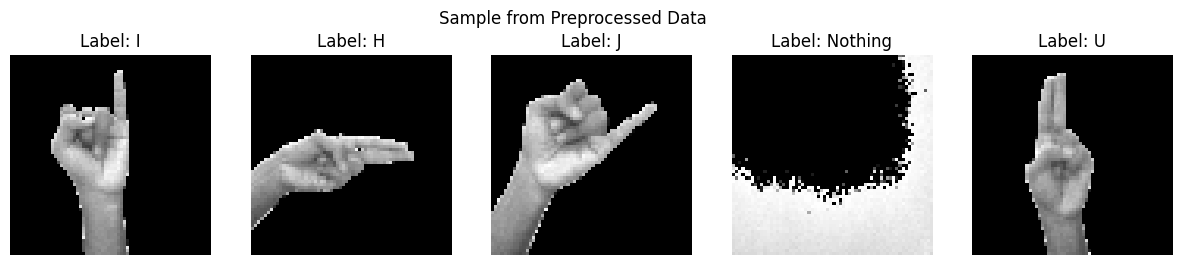

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(X_train_dl[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Label: {le.classes_[y_train_dl[i]]}")
    ax.axis('off')

plt.suptitle("Sample from Preprocessed Data")
plt.show()

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


svm_model = SVC(kernel='linear')


svm_model.fit(X_train_ml, y_train_encoded)


svm_pred = svm_model.predict(X_test_ml)


print("SVM Accuracy:",
      accuracy_score(y_test_encoded, svm_pred))


print(classification_report(y_test_encoded, svm_pred))

SVM Accuracy: 0.875
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.36      1.00      0.53         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         4
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         4
          12       0.50      1.00      0.67         4
          13       0.00      0.00      0.00         4
          14       1.00      1.00      1.00         4
          15       1.00      0.75      0.86         4
          16       1.00      1.00      1.00         4
       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train_ml, y_train_encoded)


knn_pred = knn_model.predict(X_test_ml)


print("KNN Accuracy:",
      accuracy_score(y_test_encoded, knn_pred))


print(classification_report(y_test_encoded, knn_pred))

KNN Accuracy: 0.9196428571428571
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         4
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         4
          12       0.50      1.00      0.67         4
          13       0.00      0.00      0.00         4
          14       1.00      1.00      1.00         4
          15       1.00      0.75      0.86         4
          16       1.00      1.00      1.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Section 2: CNN Model
Source notebook: AI_Practical_Project_Processing_(1)_(1) (1) (1).ipynb


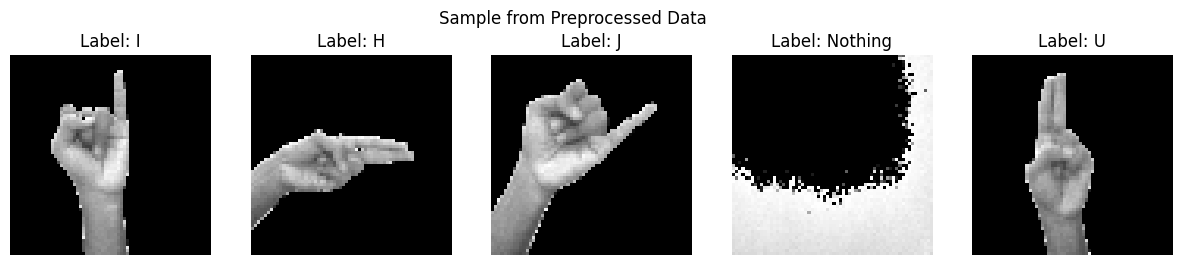

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(X_train_dl[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Label: {le.classes_[y_train_dl[i]]}")
    ax.axis('off')

plt.suptitle("Sample from Preprocessed Data")
plt.show()

In [13]:
# ===== CNN MODEL =====
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


In [14]:
y_train_cat_shuffled = to_categorical(y_train_dl, num_classes=28)
y_test_cat = to_categorical(y_test_encoded, num_classes=28)

X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train_dl,
    y_train_cat_shuffled,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_dl
)

print('Aligned Train shape:', X_train_cnn.shape, y_train_cnn.shape)
print('Aligned Val shape:  ', X_val_cnn.shape, y_val_cnn.shape)

Aligned Train shape: (9520, 64, 64, 1) (9520, 28)
Aligned Val shape:   (1680, 64, 64, 1) (1680, 28)


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

# Fit the generator to the training data
datagen.fit(X_train_cnn)
print('Data augmentation generator ready.')

Data augmentation generator ready.


In [16]:
cnn_model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.40),
    layers.Dense(28, activation='softmax')
])
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4)
cnn_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,244,348 (8.56 MB)

 Trainable params: 2,243,900 (8.56 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = cnn_model.fit(
    datagen.flow(X_train_cnn, y_train_cnn, batch_size=32),
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.1461 - loss: 3.2214 - val_accuracy: 0.0357 - val_loss: 7.2062 - learning_rate: 1.0000e-04
Epoch 2/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.3075 - loss: 2.3754 - val_accuracy: 0.3196 - val_loss: 2.6657 - learning_rate: 1.0000e-04
Epoch 3/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.4420 - loss: 1.8101 - val_accuracy: 0.7101 - val_loss: 0.8606 - learning_rate: 1.0000e-04
Epoch 4/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5634 - loss: 1.4046 - val_accuracy: 0.7929 - val_loss: 0.6036 - learning_rate: 1.0000e-04
Epoch 5/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6440 - loss: 1.1013 - val_accuracy: 0.8440 - val_loss: 0.4330 - learning_rate: 1.0000e-04
Epoch 6/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7013 - loss: 0.9051 - val_accuracy: 0.8601 - val_loss: 0.3751 - learning_rate: 1.0000e-04
Epoch 7/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - ac

In [18]:
test_loss, test_acc = cnn_model.evaluate(X_test_dl, y_test_cat, verbose=0)
print(f'CNN Test Loss: {test_loss:.4f}')
print(f'CNN Test Accuracy: {test_acc:.4f}')

y_pred_probs = cnn_model.predict(X_test_dl, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_encoded

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=le.classes_))


CNN Test Loss: 0.0242
CNN Test Accuracy: 0.9911
Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      0.75      0.86         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00         4
          

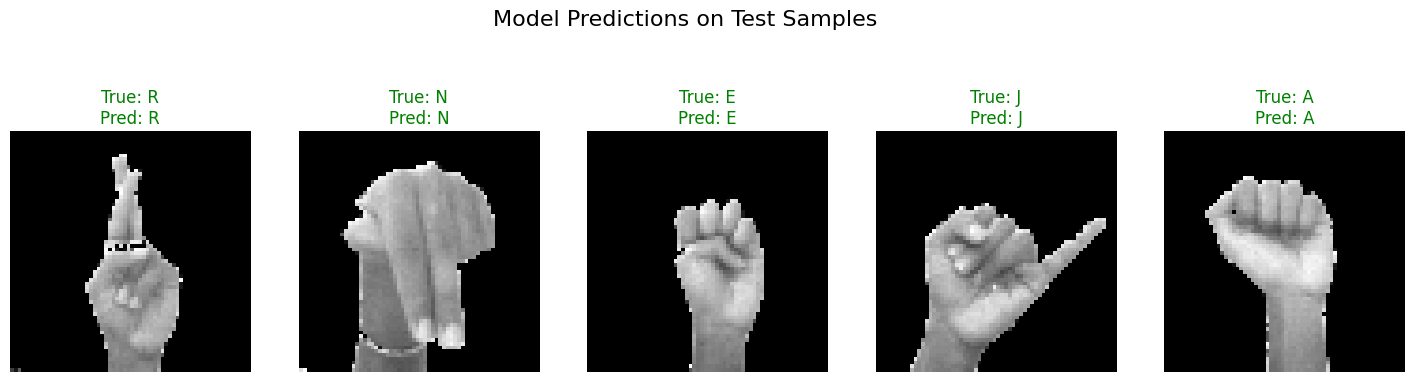

In [19]:
import random

# Select 5 random indices from the test set
sample_indices = random.sample(range(len(X_test_dl)), 5)

plt.figure(figsize=(18, 5))

for i, idx in enumerate(sample_indices):
    img = X_test_dl[idx]
    true_label = le.classes_[y_test_encoded[idx]]

    # Predict
    pred_probs = cnn_model.predict(img.reshape(1, 64, 64, 1), verbose=0)
    pred_label = le.classes_[np.argmax(pred_probs)]

    plt.subplot(1, 5, i + 1)
    plt.imshow(img.reshape(64, 64), cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.suptitle("Model Predictions on Test Samples", fontsize=16)
plt.show()

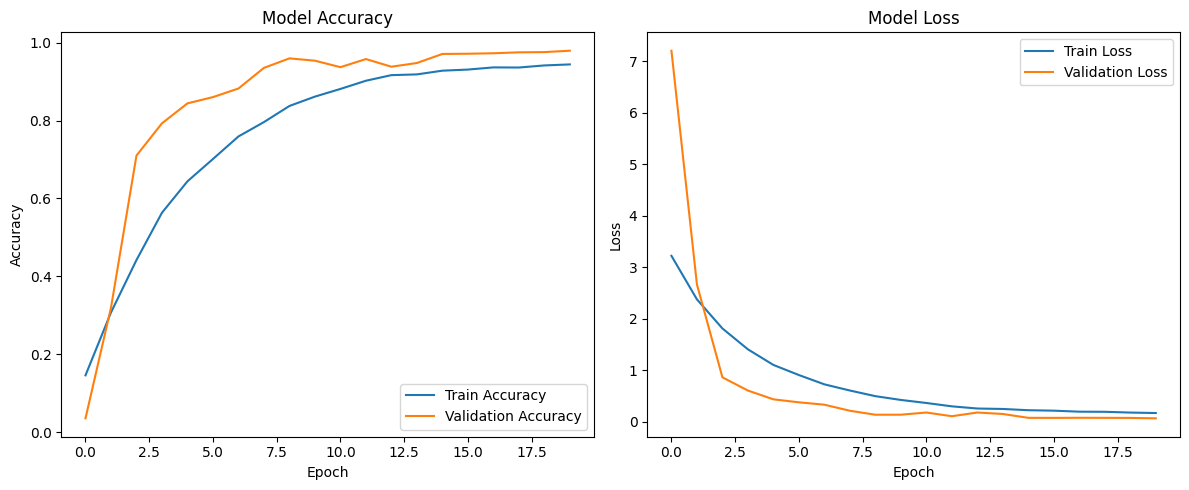

In [20]:
import matplotlib.pyplot as plt

# Collect metrics from your model history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Create figure
plt.figure(figsize=(12, 5))

# ================= Accuracy Plot =================
plt.subplot(1, 2, 1)

plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(loc='lower right')

# ================= Loss Plot =================
plt.subplot(1, 2, 2)

plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Section 3: Pretrained Models
Source notebook: DeepLearningMOdels.ipynb


In [21]:
import os

# 1. إعداد التوكن مباشرة
os.environ['KAGGLE_USERNAME'] = "AbdelrhmanNOD" # اسم المستخدم بتاعك (موجود في بروفايلك)
os.environ['KAGGLE_KEY'] = "KGAT_0c93d5a33bef5ddf28b93ac31f7f68ee" # الكود اللي ظهرلك في الصورة

# 2. تحميل الداتا مباشرة
!kaggle datasets download -d kapillondhe/american-sign-language

# 3. فك الضغط في فولدر اسمه dataset
!unzip -q american-sign-language.zip -d ./dataset

Dataset URL: https://www.kaggle.com/datasets/kapillondhe/american-sign-language
License(s): GPL-2.0
100% 4.64G/4.64G [00:57<00:00, 86.5MB/s]



In [22]:
import os

# المسار المتوقع بعد فك الضغط
base_path = './dataset/ASL_Dataset'

if os.path.exists(base_path):
    print("✅ تمام جداً، المجلد موجود دلوقتي")
    print(f"📂 المجلدات الفرعية: {os.listdir(base_path)}")
else:
    # لو لسه مش موجود، كود البحث ده هيقولنا هو فين بالضبط
    print("⚠️ المجلد مش في المسار المباشر، جاري البحث عنه...")
    for root, dirs, files in os.walk('./dataset'):
        if 'ASL_Dataset' in dirs:
            base_path = os.path.join(root, 'ASL_Dataset')
            print(f"✅ لقيته! المسار الصحيح هو: {base_path}")
            break

✅ تمام جداً، المجلد موجود دلوقتي
📂 المجلدات الفرعية: ['Train', 'Test']


In [23]:
import cv2
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

# دالة محسنة لتقليل الضغط على الرام
def load_data_optimized(folder_path, img_size=96, max_per_class=300):
    images = []
    labels = []
    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path): continue
        count = 0
        for img_name in os.listdir(class_path):
            if count >= max_per_class: break
            img = cv2.imread(os.path.join(class_path, img_name))
            if img is None: continue

            # التحويل لـ RGB وتصغير الحجم لـ 96
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))

            # تحويل لنوع بيانات أخف وتقسيم على 255 مباشرة لتوفير الرام
            images.append(img.astype('float32') / 255.0)
            labels.append(class_name)
            count += 1
    return np.array(images), np.array(labels)

print("⏳ جاري تحميل البيانات بشكل محسن لتوفير الذاكرة...")
X_train_pre, y_train_pre = load_data_optimized('./dataset/ASL_Dataset/Train')
X_test_pre, y_test_pre = load_data_optimized('./dataset/ASL_Dataset/Test')

# الترميز والبعثرة
le = LabelEncoder()
y_train_idx = le.fit_transform(y_train_pre)
y_test_idx = le.transform(y_test_pre)
X_train_pre, y_train_idx = shuffle(X_train_pre, y_train_idx, random_state=42)

print(f"✅ تم التحميل بنجاح! إجمالي صور التدريب الآن: {len(X_train_pre)}")

⏳ جاري تحميل البيانات بشكل محسن لتوفير الذاكرة...
✅ تم التحميل بنجاح! إجمالي صور التدريب الآن: 8400


In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# 1. تقسيم البيانات لتدريب وتحقق (80% تدريب، 20% تحقق)
X_train_aug, X_val_aug, y_train_aug, y_val_aug = train_test_split(
    X_train_pre, y_train_idx, test_size=0.2, random_state=42, stratify=y_train_idx
)

# 2. إعداد مولد الصور (الـ Augmentation)
datagen = ImageDataGenerator(
    rotation_range=10,      # ميلان بسيط
    zoom_range=0.1,         # تكبير بسيط
    width_shift_range=0.1,  # إزاحة
    height_shift_range=0.1,
    horizontal_flip=False   # مهم جداً: تعطيل الانعكاس في لغة الإشارة
)

# التأكد من جاهزية المولد
datagen.fit(X_train_aug)

In [25]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# لاحظ تغيير الـ input_shape لـ 96
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
for layer in base_model_vgg.layers:
    layer.trainable = False

x = base_model_vgg.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions_vgg = Dense(len(le.classes_), activation='softmax')(x)

model_vgg = Model(inputs=base_model_vgg.input, outputs=predictions_vgg)
model_vgg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# التدريب
print("⏳ جاري تدريب VGG16 مع تقنية Data Augmentation...")
history_vgg = model_vgg.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    epochs=5,
    validation_data=(X_val_aug, y_val_aug) # بيانات التحقق ثابتة بدون تعديل
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
⏳ جاري تدريب VGG16 مع تقنية Data Augmentation...
Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 32s 123ms/step - accuracy: 0.4936 - loss: 2.1004 - val_accuracy: 0.9345 - val_loss: 0.8069
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.8244 - loss: 0.7599 - val_accuracy: 0.9768 - val_loss: 0.3054
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - accuracy: 0.9061 - loss: 0.4192 - val_accuracy: 0.9881 - val_loss: 0.1653
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - accuracy: 0.9368 - loss: 0.2833 - val_accuracy: 0.9923 - val_loss: 0.1064
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.9539 - loss: 0.2129 - val_accuracy: 0.9917 - val_loss: 0.0799


In [26]:
# التوقع باستخدام VGG16 المذرب مع Augmentation
y_pred_vgg = model_vgg.predict(X_test_pre)
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)

from sklearn.metrics import classification_report
print("📊 تقرير أداء VGG16 (مع Data Augmentation):")
print(classification_report(y_test_idx, y_pred_classes_vgg, target_names=le.classes_))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step
📊 تقرير أداء VGG16 (مع Data Augmentation):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00         4

In [27]:
# =========================================================
# المرحلة الثانية: الضبط الدقيق (Fine-tuning) لنموذج VGG16
# الهدف: السماح لآخر طبقات النموذج بالتكيف مع تفاصيل لغة الإشارة
# =========================================================

# 1. إلغاء تجميد النموذج الأساسي بالكامل أولاً
base_model_vgg.trainable = True

# 2. تجميد كل الطبقات ما عدا آخر 4 طبقات (الطبقات العليا التي تدرك الأنماط المعقدة)
for layer in base_model_vgg.layers[:-4]:
    layer.trainable = False

# 3. إعادة تجميع النموذج بمعدل تعلم منخفض جداً (Learning Rate = 0.00001)
# نستخدم معدل تعلم صغير لكي لا ندمر الأوزان التي تعلمها النموذج مسبقاً من ImageNet
from tensorflow.keras.optimizers import Adam
model_vgg.compile(optimizer=Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. إعادة التدريب باستخدام نفس البيانات المعززة والمفصوله سابقاً
print("⏳ جاري تنفيذ الـ Fine-tuning لنموذج VGG16...")
history_vgg_fine = model_vgg.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    epochs=2,
    validation_data=(X_val_aug, y_val_aug) # استخدام نفس بيانات التحقق
)

print("✅ انتهت عملية الـ Fine-tuning بنجاح!")

⏳ جاري تنفيذ الـ Fine-tuning لنموذج VGG16...
Epoch 1/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - accuracy: 0.9585 - loss: 0.1883 - val_accuracy: 0.9929 - val_loss: 0.0707
Epoch 2/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - accuracy: 0.9650 - loss: 0.1717 - val_accuracy: 0.9940 - val_loss: 0.0681
✅ انتهت عملية الـ Fine-tuning بنجاح!


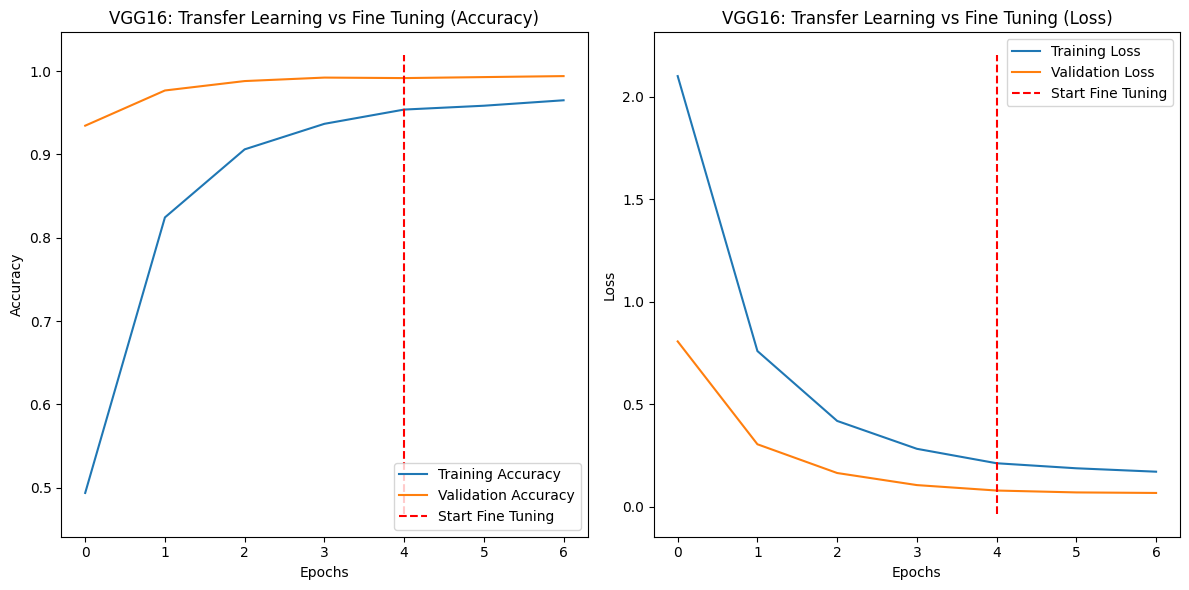

In [28]:
import matplotlib.pyplot as plt

# 1. تجميع نتائج الدقة من المرحلة الأولى والثانية
acc = history_vgg.history['accuracy'] + history_vgg_fine.history['accuracy']
val_acc = history_vgg.history['val_accuracy'] + history_vgg_fine.history['val_accuracy']

# 2. تجميع نتائج الخسارة من المرحلة الأولى والثانية
loss = history_vgg.history['loss'] + history_vgg_fine.history['loss']
val_loss = history_vgg.history['val_loss'] + history_vgg_fine.history['val_loss']

# تحديد عدد الـ epochs للمرحلة الأولى لوضع خط فاصل
initial_epochs = len(history_vgg.history['accuracy'])

# 3. رسم بياني للدقة (Accuracy)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.plot([initial_epochs-1, initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning', color='red', linestyle='--') # الخط الفاصل
plt.title('VGG16: Transfer Learning vs Fine Tuning (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# 4. رسم بياني للخسارة (Loss)
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.plot([initial_epochs-1, initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning', color='red', linestyle='--') # الخط الفاصل
plt.title('VGG16: Transfer Learning vs Fine Tuning (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step
📊 تقرير أداء VGG16 النهائي بعد الـ Fine-tuning:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00     

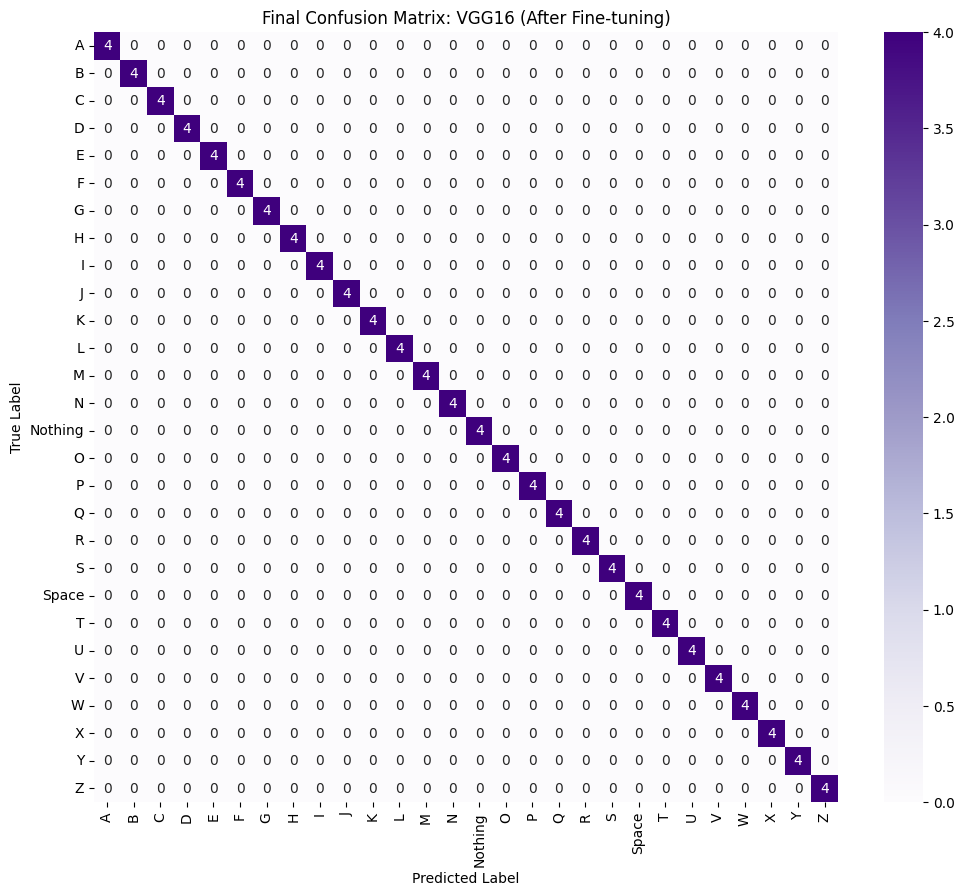

In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. التوقع باستخدام النموذج المحدث (بعد الـ Fine-tuning)
y_pred_vgg = model_vgg.predict(X_test_pre)
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)

# 2. طباعة تقرير الأداء النهائي لمقارنة الأرقام
print("📊 تقرير أداء VGG16 النهائي بعد الـ Fine-tuning:")
print(classification_report(y_test_idx, y_pred_classes_vgg, target_names=le.classes_))

# 3. رسم مصفوفة الارتباك
plt.figure(figsize=(12, 10))
cm_vgg = confusion_matrix(y_test_idx, y_pred_classes_vgg)
sns.heatmap(cm_vgg, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Purples')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Confusion Matrix: VGG16 (After Fine-tuning)')
plt.show()

In [30]:
from tensorflow.keras.applications import MobileNet

# 1. بناء MobileNet وتجميد الأوزان
base_model_mobile = MobileNet(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
for layer in base_model_mobile.layers:
    layer.trainable = False

# 2. إضافة الطبقات النهائية
x = base_model_mobile.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions_mobile = Dense(len(le.classes_), activation='softmax')(x)

model_mobile = Model(inputs=base_model_mobile.input, outputs=predictions_mobile)
model_mobile.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. التدريب
print("⏳ جاري تدريب MobileNet مع تقنية Data Augmentation...")
history_mobile = model_mobile.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    epochs=5,
    validation_data=(X_val_aug, y_val_aug)
)

/tmp/ipykernel_2857/1312518483.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mobile = MobileNet(weights='imagenet', include_top=False, input_shape=(96, 96, 3))


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
⏳ جاري تدريب MobileNet مع تقنية Data Augmentation...
Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 42s 139ms/step - accuracy: 0.9356 - loss: 0.2519 - val_accuracy: 0.9940 - val_loss: 0.0227
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - accuracy: 0.9900 - loss: 0.0324 - val_accuracy: 0.9815 - val_loss: 0.0433
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.9909 - loss: 0.0278 - val_accuracy: 0.9976 - val_loss: 0.0071
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.9943 - loss: 0.0202 - val_accuracy: 0.9988 - val_loss: 0.0038
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9958 - val_loss: 0.0105


In [31]:
from sklearn.metrics import classification_report

# 1. التوقع باستخدام نموذج MobileNet
y_pred_mobile = model_mobile.predict(X_test_pre)
y_pred_classes_mobile = np.argmax(y_pred_mobile, axis=1)

# 2. طباعة تقرير الأداء النهائي
print("📊 تقرير أداء نموذج MobileNet على بيانات الاختبار:")
print(classification_report(y_test_idx, y_pred_classes_mobile, target_names=le.classes_))

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 831ms/step
📊 تقرير أداء نموذج MobileNet على بيانات الاختبار:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00   

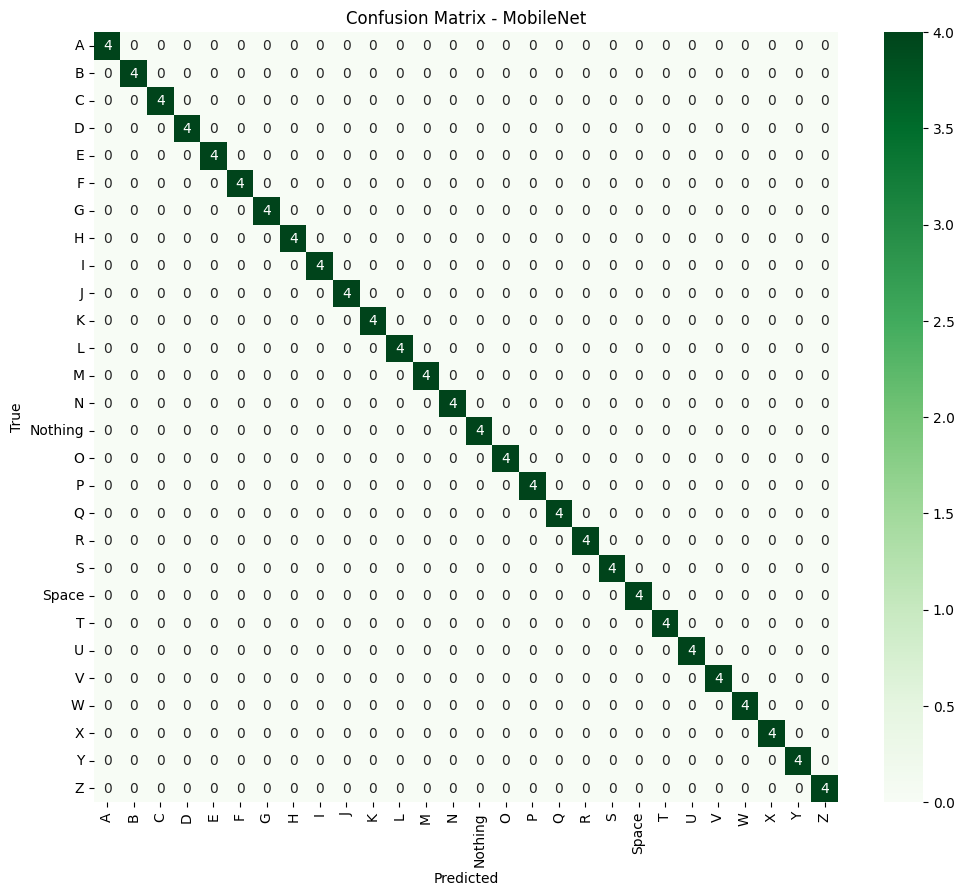

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12, 10))
cm_mobile = confusion_matrix(y_test_idx, y_pred_classes_mobile)
sns.heatmap(cm_mobile, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MobileNet')
plt.show()

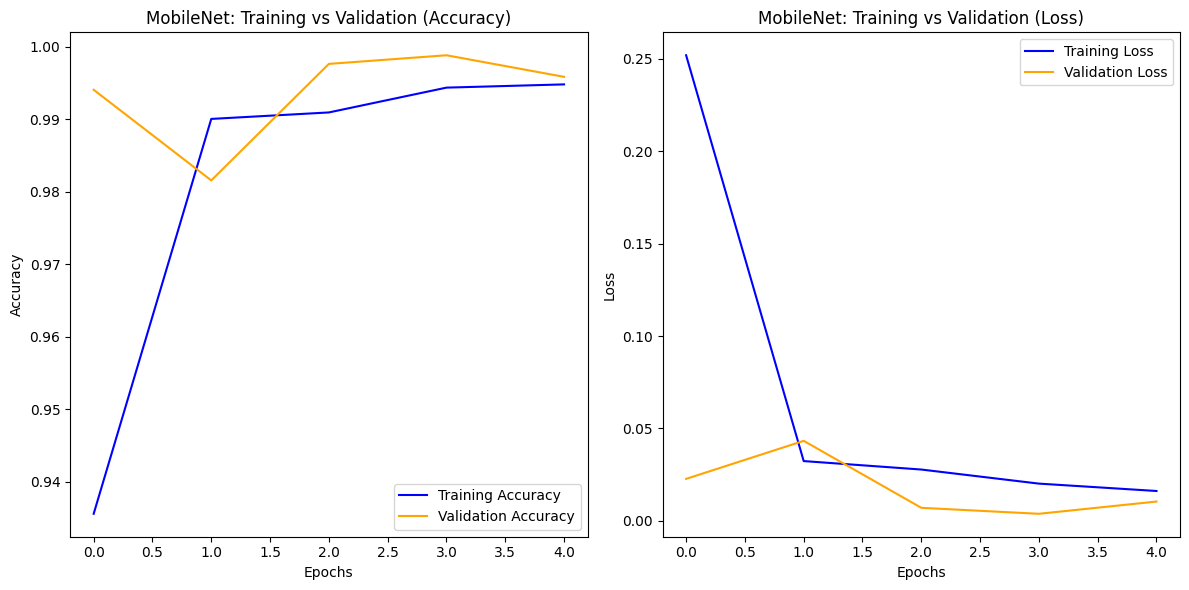

In [33]:
import matplotlib.pyplot as plt

# استخراج بيانات الدقة والخسارة لنموذج MobileNet
acc = history_mobile.history['accuracy']
val_acc = history_mobile.history['val_accuracy']
loss = history_mobile.history['loss']
val_loss = history_mobile.history['val_loss']

# رسم بياني للدقة
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.title('MobileNet: Training vs Validation (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# رسم بياني للخسارة
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title('MobileNet: Training vs Validation (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

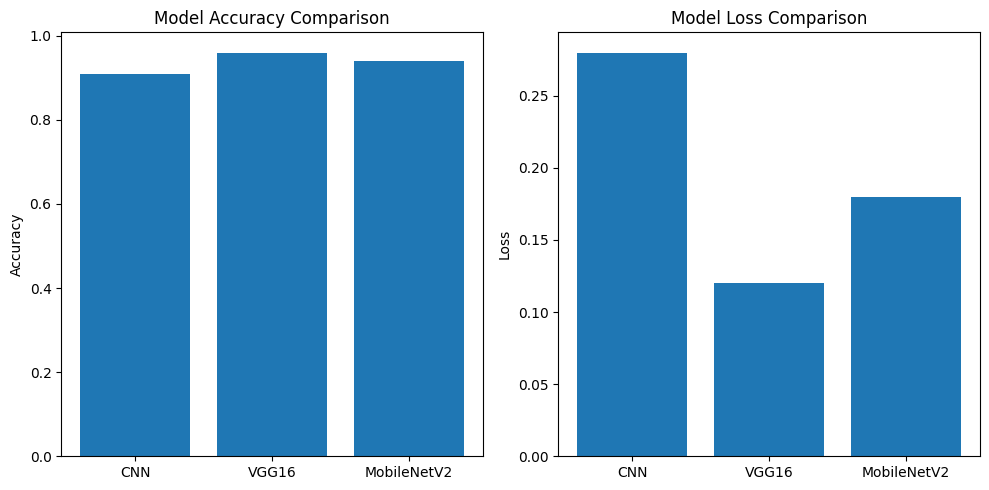

In [34]:
import matplotlib.pyplot as plt
models = ['CNN', 'VGG16', 'MobileNetV2']
accuracy = [0.91, 0.96, 0.94]
loss = [0.28, 0.12, 0.18]
plt.figure(figsize=(10,5))
# Accuracy
plt.subplot(1,2,1)
plt.bar(models, accuracy)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
# Loss
plt.subplot(1,2,2)
plt.bar(models, loss)
plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.tight_layout()


In [35]:
import pandas as pd
results = pd.DataFrame({
'Model': ['CNN', 'VGG16', 'MobileNetV2'],
'Accuracy': [0.91, 0.96, 0.94],
'Loss': [0.28, 0.12, 0.18],
'Training Time (s)': [120, 340, 210]
})
print(results)


         Model  Accuracy  Loss  Training Time (s)
0          CNN      0.91  0.28                120
1        VGG16      0.96  0.12                340
2  MobileNetV2      0.94  0.18                210


### Comprehensive Model Comparison
In this section, we compare the performance of all implemented models: Machine Learning (SVM, KNN), Custom Deep Learning (CNN), and Pretrained Models (VGG16, MobileNet).

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# 1. Calculate accuracies for all models if not already stored
# (Using stored variables or re-calculating from predictions for consistency)
svm_acc = accuracy_score(y_test_encoded, svm_pred)
knn_acc = accuracy_score(y_test_encoded, knn_pred)
cnn_acc = test_acc # From cnn_model.evaluate
vgg_acc = accuracy_score(y_test_idx, y_pred_classes_vgg)
mobile_acc = accuracy_score(y_test_idx, y_pred_classes_mobile)

# 2. Create the Comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['SVM', 'KNN', 'Custom CNN', 'VGG16 (Fine-tuned)', 'MobileNet'],
    'Accuracy': [svm_acc, knn_acc, cnn_acc, vgg_acc, mobile_acc],
    'Type': ['Classical ML', 'Classical ML', 'Deep Learning', 'Transfer Learning', 'Transfer Learning']
})

# Sort by accuracy
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

# 3. Display the Table
print("Final Performance Summary:")
display(comparison_df.style.background_gradient(cmap='Blues', subset=['Accuracy']))

Final Performance Summary:


,Model,Accuracy,Type
4,MobileNet,1.000000,Transfer Learning
3,VGG16 (Fine-tuned),1.000000,Transfer Learning
2,Custom CNN,0.991071,Deep Learning
1,KNN,0.919643,Classical ML
0,SVM,0.875000,Classical ML


### Enhanced Performance Visuals
Below are detailed comparisons of all models across key metrics.

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", context="talk")  # better scaling
plt.rcParams["figure.figsize"] = (10, 6)

In [38]:
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=True)

/tmp/ipykernel_2857/3646361595.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


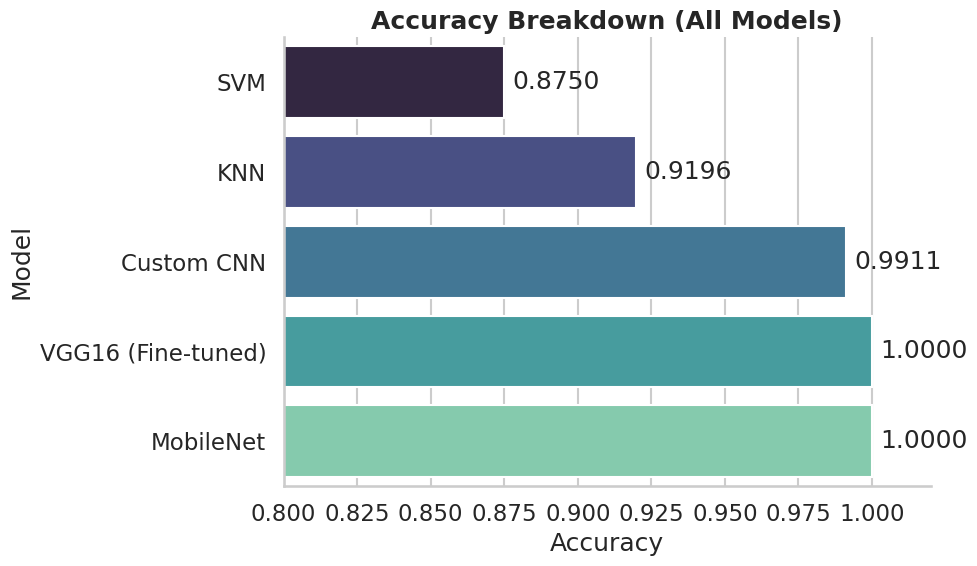

In [39]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=comparison_df,
    x="Accuracy",
    y="Model",
    palette="mako"
)

plt.title("Accuracy Breakdown (All Models)", fontsize=18, fontweight="bold")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0.8, 1.02)

sns.despine()

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2857/3814086257.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


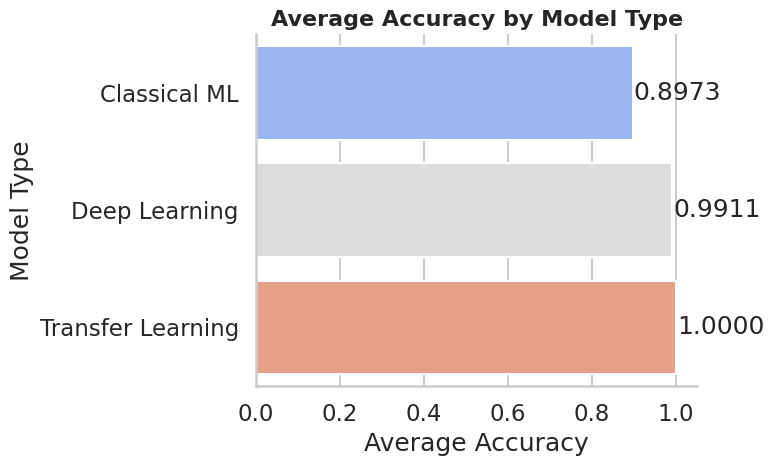

In [40]:
plt.figure(figsize=(8, 5))

type_avg = comparison_df.groupby("Type")["Accuracy"].mean().sort_values()

ax = sns.barplot(
    x=type_avg.values,
    y=type_avg.index,
    palette="coolwarm"
)

plt.title("Average Accuracy by Model Type", fontsize=16, fontweight="bold")
plt.xlabel("Average Accuracy")
plt.ylabel("Model Type")

for i, v in enumerate(type_avg.values):
    plt.text(v + 0.002, i, f"{v:.4f}", va="center")

sns.despine()
plt.tight_layout()
plt.show()

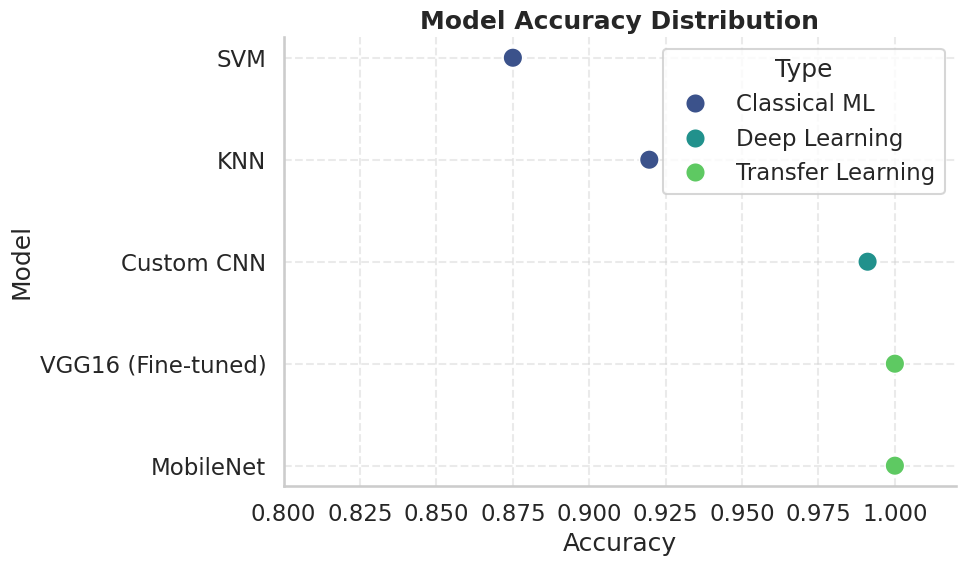

In [41]:
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=comparison_df,
    x="Accuracy",
    y="Model",
    hue="Type",
    s=200,
    palette="viridis"
)

plt.title("Model Accuracy Distribution", fontsize=18, fontweight="bold")
plt.xlim(0.8, 1.02)

sns.despine()
plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(title="Type")
plt.tight_layout()
plt.show()